# 🎓 Dự Đoán Trầm Cảm Sinh Viên Dựa Trên Áp Lực Học Tập, Giờ Ngủ & Lối Sống
## Khai Phá Dữ Liệu — Project Cuối Kỳ

---

| | |
|---|---|
| **Đề tài** | Dựa vào áp lực học tập, giờ ngủ, stress tài chính và lối sống, sinh viên có bị trầm cảm không? |
| **Dataset** | [Student Depression Dataset](https://www.kaggle.com/datasets/adilshamim8/student-depression-dataset) — Kaggle (adilshamim8) |
| **Loại bài toán** | Binary Classification |
| **Biến mục tiêu** | `Depression` (1 = có trầm cảm, 0 = không) |
| **Số mẫu** | 27,901 sinh viên |
| **Thuật toán** | Logistic Regression · Decision Tree · Random Forest · XGBoost |

---

### Cấu trúc báo cáo
| Chương | Nội dung |
|---|---|
| **Chương 1** | Giới thiệu — bối cảnh, định nghĩa bài toán, vai trò data mining |
| **Chương 2** | Mô tả dữ liệu — kích thước, kiểu dữ liệu, thống kê mô tả |
| **Chương 3** | Phương pháp — quy trình, nguyên lý thuật toán, tiêu chí đánh giá |
| **Chương 4** | Thực nghiệm — EDA, tiền xử lý, huấn luyện |
| **Chương 5** | Kết quả — đánh giá mô hình, trả lời câu hỏi nghiên cứu |
| **Chương 6** | Thảo luận & Kết luận |

## 0. Cài đặt thư viện

In [1]:
# Bỏ comment nếu chưa cài
# !pip install notebook ipykernel pandas numpy scikit-learn matplotlib seaborn xgboost

## 1. Import thư viện & Cấu hình

In [2]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from scipy.stats import pointbiserialr, chi2_contingency, ttest_ind

from sklearn.model_selection  import (train_test_split, cross_val_score,
                                       StratifiedKFold, learning_curve)
from sklearn.preprocessing    import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble         import RandomForestClassifier
from sklearn.metrics          import (accuracy_score, precision_score, recall_score,
                                       f1_score, roc_auc_score, confusion_matrix,
                                       ConfusionMatrixDisplay, roc_curve,
                                       classification_report)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
os.makedirs('charts', exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# ── Hằng số ──────────────────────────────────────────────────────────────────
DATA_PATH    = './data/Student_Depression_Dataset.csv'   # đổi đường dẫn nếu cần
RANDOM_STATE = 42
TARGET_COL   = 'Depression'
COLORS       = {'0': '#4CAF50', '1': '#F44336',
                'blue': '#2196F3', 'orange': '#FF9800', 'purple': '#9C27B0'}

print("✅ Import hoàn tất!")
print(f"   Sẽ đọc file: {DATA_PATH}")

✅ Import hoàn tất!
   Sẽ đọc file: ./data/Student_Depression_Dataset.csv


## Chương 1 — Giới thiệu

### 1.1 Bối cảnh bài toán

Trầm cảm trong sinh viên đang là vấn đề sức khỏe tâm thần nghiêm trọng trên toàn cầu.
Theo WHO (2023), trầm cảm ảnh hưởng đến hơn 280 triệu người, và nhóm sinh viên
đại học là một trong những nhóm dễ bị tổn thương nhất do áp lực học tập, thi cử,
tài chính và sự thay đổi môi trường sống.

Các nghiên cứu chỉ ra rằng áp lực học tập cao, thiếu ngủ (<5–6 giờ/ngày),
stress tài chính và chế độ ăn không lành mạnh là những yếu tố nguy cơ chính
dẫn đến trầm cảm ở sinh viên (Noviandy et al., 2025; Zhou et al., 2021).
Tuy nhiên, việc phát hiện sớm vẫn còn khó khăn do thiếu công cụ sàng lọc
tự động và chi phí tư vấn tâm lý cao.

### 1.2 Định nghĩa bài toán

| Thành phần | Mô tả |
|---|---|
| **Input (đầu vào)** | Áp lực học tập (`Academic Pressure`), giờ ngủ (`Sleep Duration`), stress tài chính (`Financial Stress`), chế độ ăn (`Dietary Habits`), tiền sử gia đình, suy nghĩ tự tử, CGPA, số giờ học/làm... |
| **Output (đầu ra)** | `Depression`: 1 = có trầm cảm, 0 = không trầm cảm |
| **Loại bài toán** | Binary Classification (phân loại nhị phân) |
| **Thuật toán** | Logistic Regression, Decision Tree, Random Forest, XGBoost |

### 1.3 Giải pháp hiện tại

- **Bảng câu hỏi lâm sàng** (PHQ-9, BDI-II): chuẩn nhưng cần chuyên gia, tốn thời gian
- **Tư vấn tâm lý trực tiếp**: hiệu quả cao nhưng chi phí lớn, nhiều sinh viên ngại tiếp cận
- **Ứng dụng self-help** (Headspace, Calm): hỗ trợ nhưng không phát hiện chủ động

### 1.4 Vai trò của khai phá dữ liệu

Áp dụng thuật toán học máy cho phép xây dựng mô hình tự động học mối quan hệ
giữa các yếu tố học tập, lối sống và mức độ trầm cảm từ dữ liệu khảo sát thực tế.
Mô hình có thể triển khai quy mô lớn, chi phí thấp, không cần chuyên gia tâm lý can thiệp trực tiếp.

### 1.5 Ứng dụng dự kiến

- Hệ thống cảnh báo sớm tích hợp vào cổng thông tin sinh viên
- Hỗ trợ trung tâm tư vấn tâm lý trường đại học sàng lọc sinh viên cần can thiệp
- Nghiên cứu tác động của môi trường học tập lên sức khỏe tâm thần

## Chương 2 — Mô tả dữ liệu

### 2.1 Tải dữ liệu & Thông tin tổng quan

In [3]:
df = pd.read_csv(DATA_PATH)

print(f"📊 Kích thước: {df.shape[0]:,} dòng × {df.shape[1]} cột")
print(f"📍 Nguồn: https://www.kaggle.com/datasets/adilshamim8/student-depression-dataset")
print()
df.head()

📊 Kích thước: 27,901 dòng × 18 cột
📍 Nguồn: https://www.kaggle.com/datasets/adilshamim8/student-depression-dataset



,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


### 2.2 Kiểu dữ liệu & Cấu trúc

In [4]:
info_df = pd.DataFrame({
    'Cột': df.columns,
    'Kiểu dữ liệu': df.dtypes.values,
    'Số giá trị không null': df.notnull().sum().values,
    'Số giá trị unique': df.nunique().values,
    'Ví dụ': [str(df[c].dropna().iloc[0]) if len(df[c].dropna()) > 0 else 'N/A'
              for c in df.columns]
})
print(info_df.to_string(index=False))

                                  Cột Kiểu dữ liệu  Số giá trị không null  Số giá trị unique         Ví dụ
                                   id        int64                  27901              27901             2
                               Gender       object                  27901                  2          Male
                                  Age      float64                  27901                 34          33.0
                                 City       object                  27901                 52 Visakhapatnam
                           Profession       object                  27901                 14       Student
                    Academic Pressure      float64                  27901                  6           5.0
                        Work Pressure      float64                  27901                  3           0.0
                                 CGPA      float64                  27901                332          8.97
                   Study Satisfaction

### 2.3 Missing Values

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({'Số thiếu': missing, 'Tỷ lệ (%)': missing_pct})
miss_df = miss_df[miss_df['Số thiếu'] > 0]

if len(miss_df) == 0:
    print("✅ Không có missing values!")
else:
    print(f"⚠️  Phát hiện {miss_df['Số thiếu'].sum()} giá trị thiếu:")
    print(miss_df.to_string())

⚠️  Phát hiện 3 giá trị thiếu:
                  Số thiếu  Tỷ lệ (%)
Financial Stress         3       0.01


### 2.4 Thống kê mô tả — biến số

In [6]:
num_cols = ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA',
            'Study Satisfaction', 'Job Satisfaction',
            'Work/Study Hours', 'Financial Stress']
df[num_cols].describe().round(3)

,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress
count,27901.000,27901.000,27901.000,27901.000,27901.000,27901.000,27901.000,27898.000
mean,25.822,3.141,0.000,7.656,2.944,0.001,7.157,3.140
std,4.906,1.381,0.044,1.471,1.361,0.044,3.708,1.437
min,18.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000
25%,21.000,2.000,0.000,6.290,2.000,0.000,4.000,2.000
50%,25.000,3.000,0.000,7.770,3.000,0.000,8.000,3.000
75%,30.000,4.000,0.000,8.920,4.000,0.000,10.000,4.000
max,59.000,5.000,5.000,10.000,5.000,4.000,12.000,5.000


### 2.5 Phân bố biến phân loại

In [7]:
cat_cols = ['Gender', 'Sleep Duration', 'Dietary Habits',
            'Have you ever had suicidal thoughts ?',
            'Family History of Mental Illness', 'Degree', 'Profession']

for c in cat_cols:
    counts = df[c].value_counts()
    print(f"{'─'*52}")
    print(f"  {c}")
    print(f"{'─'*52}")
    for val, cnt in counts.items():
        bar = '█' * int(cnt / len(df) * 50)
        print(f"  {str(val):<35} {cnt:>6}  ({cnt/len(df)*100:5.1f}%)  {bar}")

────────────────────────────────────────────────────
  Gender
────────────────────────────────────────────────────
  Male                                 15547  ( 55.7%)  ███████████████████████████
  Female                               12354  ( 44.3%)  ██████████████████████
────────────────────────────────────────────────────
  Sleep Duration
────────────────────────────────────────────────────
  Less than 5 hours                     8310  ( 29.8%)  ██████████████
  7-8 hours                             7346  ( 26.3%)  █████████████
  5-6 hours                             6183  ( 22.2%)  ███████████
  More than 8 hours                     6044  ( 21.7%)  ██████████
  Others                                  18  (  0.1%)  
────────────────────────────────────────────────────
  Dietary Habits
────────────────────────────────────────────────────
  Unhealthy                            10317  ( 37.0%)  ██████████████████
  Moderate                              9921  ( 35.6%)  ████████████

### 2.6 Phân bố biến mục tiêu `Depression`

Phân bố Depression:
  0 — Không trầm cảm: 11,565 (41.5%)
  1 — Có trầm cảm:    16,336 (58.5%)


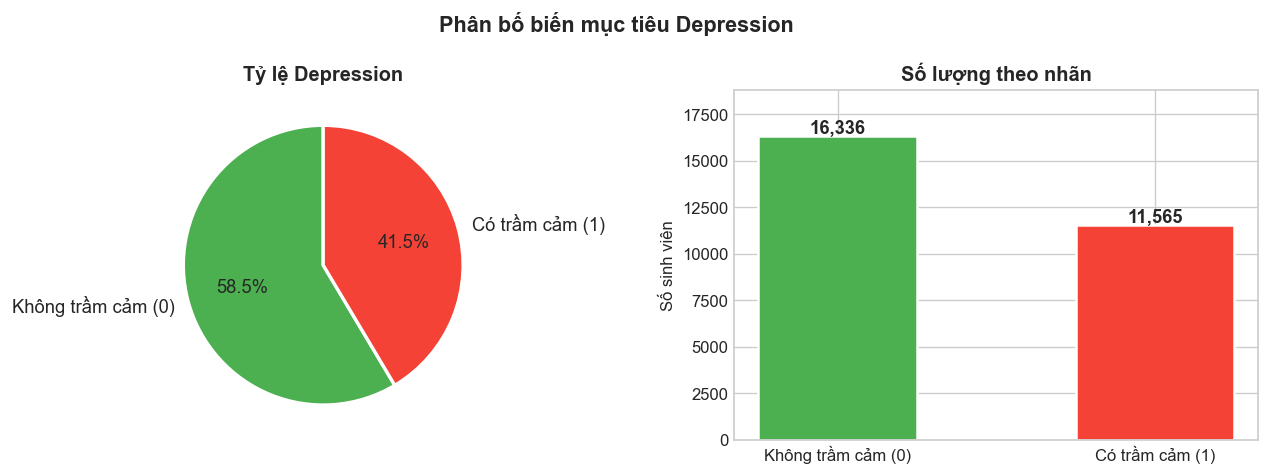

In [8]:
dep_counts = df[TARGET_COL].value_counts()
dep_pct    = df[TARGET_COL].value_counts(normalize=True) * 100

print("Phân bố Depression:")
print(f"  0 — Không trầm cảm: {dep_counts[0]:,} ({dep_pct[0]:.1f}%)")
print(f"  1 — Có trầm cảm:    {dep_counts[1]:,} ({dep_pct[1]:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Pie
axes[0].pie(dep_counts, labels=['Không trầm cảm (0)', 'Có trầm cảm (1)'],
            colors=[COLORS['0'], COLORS['1']], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 11})
axes[0].set_title('Tỷ lệ Depression', fontweight='bold')

# Bar
bars = axes[1].bar(['Không trầm cảm (0)', 'Có trầm cảm (1)'],
                   dep_counts.values,
                   color=[COLORS['0'], COLORS['1']],
                   edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, dep_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('Số lượng theo nhãn', fontweight='bold')
axes[1].set_ylabel('Số sinh viên')
axes[1].set_ylim(0, max(dep_counts.values) * 1.15)

plt.suptitle('Phân bố biến mục tiêu Depression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/01_target_distribution.png', bbox_inches='tight')
plt.show()

### 2.7 Giả thiết khi thu thập dữ liệu

- Dữ liệu được thu thập qua khảo sát tự khai báo từ sinh viên tại nhiều trường đại học
- Nhãn `Depression` được xác định dựa trên tiêu chí lâm sàng hoặc self-report có kiểm chứng
- Các biến áp lực học tập, tài chính được đo theo thang điểm 1–5
- Giả định rằng sinh viên trả lời trung thực và không có sai lệch chọn mẫu lớn

## Chương 3 — Phương pháp khai phá dữ liệu

### 3.1 Quy trình tổng thể

```
CSV (27,901 dòng × 18 cột)
        ↓
[Bước 1] Kiểm tra & xử lý missing values
        ↓
[Bước 2] Mã hóa biến phân loại (LabelEncoder / OrdinalEncoder)
        ↓
[Bước 3] EDA — phân bố, tương quan, trực quan hóa
        ↓
[Bước 4] Chia Train/Test 80/20 (stratified)
        ↓
[Bước 5] Chuẩn hóa StandardScaler
        ↓
[Bước 6] Huấn luyện 4 mô hình: LR · DT · RF · XGB
        ↓
[Bước 7] Đánh giá: Accuracy · Precision · Recall · F1 · AUC · CV-5fold
        ↓
[Bước 8] So sánh, chọn mô hình tốt nhất, phân tích Feature Importance
```

### 3.2 Nguyên lý thuật toán

#### 3.2.1 Logistic Regression
Mô hình tuyến tính dự đoán xác suất qua hàm sigmoid:
$$P(y=1|X) = \\frac{1}{1+e^{-(w^TX+b)}}$$
Ưu điểm: đơn giản, nhanh, dễ giải thích hệ số. Là baseline tốt cho bài toán nhị phân.

#### 3.2.2 Decision Tree
Phân chia dữ liệu đệ quy theo ngưỡng của từng đặc trưng, tối thiểu hóa Gini Impurity.
Ưu điểm: trực quan, có thể visualize toàn bộ cây quyết định.

#### 3.2.3 Random Forest
Ensemble của N cây Decision Tree, mỗi cây học trên bootstrap sample.
Kết quả là majority vote. Giảm variance, tránh overfitting so với single tree.

#### 3.2.4 XGBoost (Extreme Gradient Boosting)
Xây dựng cây tuần tự — cây sau sửa lỗi cây trước qua gradient descent.
Có regularization L1/L2, xử lý missing tự động, tốc độ cao.

### 3.3 Tham số mô hình

| Mô hình | Tham số chính | Lý do |
|---|---|---|
| Logistic Regression | `C=1.0`, `max_iter=1000`, `solver='lbfgs'` | Đủ vòng lặp, phù hợp multi-feature |
| Decision Tree | `max_depth=8`, `criterion='gini'` | Giới hạn độ sâu tránh overfitting |
| Random Forest | `n_estimators=200`, `max_depth=None` | 200 cây cho độ ổn định cao |
| XGBoost | `n_estimators=200`, `learning_rate=0.1`, `max_depth=5` | Tham số chuẩn cho tabular data |

### 3.4 Tiêu chí đánh giá

| Tiêu chí | Công thức | Ý nghĩa với bài toán |
|---|---|---|
| **Accuracy** | (TP+TN)/(Total) | Tỷ lệ dự đoán đúng tổng thể |
| **Precision** | TP/(TP+FP) | Trong số dự đoán trầm cảm, bao nhiêu đúng (tránh báo động giả) |
| **Recall** | TP/(TP+FN) | Trong số thực sự trầm cảm, phát hiện được bao nhiêu (quan trọng với sức khỏe) |
| **F1-score** | 2×P×R/(P+R) | Cân bằng Precision và Recall |
| **AUC-ROC** | Area under ROC | Khả năng phân biệt 2 lớp (1.0 = hoàn hảo, 0.5 = random) |
| **5-fold CV** | Mean CV accuracy | Độ ổn định khi thay đổi tập dữ liệu |

## Chương 4 — Thực nghiệm

### 4.1 Yêu cầu môi trường

| Thành phần | Phiên bản khuyến nghị |
|---|---|
| Python | 3.10+ |
| pandas | 2.x |
| numpy | 1.24+ |
| scikit-learn | 1.3+ |
| xgboost | 1.7+ |
| matplotlib / seaborn | 3.7+ / 0.12+ |
| RAM | 8 GB+ |

### 4.2 Bước 1 — Tiền xử lý dữ liệu

In [9]:
df_clean = df.copy()

# ── 1. Xử lý missing values ───────────────────────────────────────────────────
n_missing = df_clean.isnull().sum().sum()
if n_missing > 0:
    # Số: điền median; Categorical: điền mode
    num_feats = df_clean.select_dtypes(include=np.number).columns.tolist()
    cat_feats  = df_clean.select_dtypes(include='object').columns.tolist()
    for c in num_feats:
        df_clean[c].fillna(df_clean[c].median(), inplace=True)
    for c in cat_feats:
        df_clean[c].fillna(df_clean[c].mode()[0], inplace=True)
    print(f"✅ Đã xử lý {n_missing} missing values")
else:
    print("✅ Không có missing values — bỏ qua bước này")

# ── 2. Mã hóa Sleep Duration (ordinal — có thứ tự) ───────────────────────────
sleep_order = ['Less than 5 hours', '5-6 hours', '7-8 hours', 'More than 8 hours']
sleep_map   = {v: i for i, v in enumerate(sleep_order)}
df_clean['Sleep Duration Enc'] = df_clean['Sleep Duration'].map(sleep_map)
print(f"✅ Mã hóa Sleep Duration (ordinal): {sleep_map}")

# ── 3. Mã hóa Dietary Habits (ordinal) ───────────────────────────────────────
diet_map = {'Unhealthy': 0, 'Moderate': 1, 'Healthy': 2}
df_clean['Dietary Habits Enc'] = df_clean['Dietary Habits'].map(diet_map)
print(f"✅ Mã hóa Dietary Habits (ordinal):   {diet_map}")

# ── 4. Mã hóa binary ─────────────────────────────────────────────────────────
binary_cols = {
    'Gender':                               {'Male': 0, 'Female': 1},
    'Have you ever had suicidal thoughts ?':{'No': 0, 'Yes': 1},
    'Family History of Mental Illness':     {'No': 0, 'Yes': 1},
}
for col, mapping in binary_cols.items():
    df_clean[col + ' Enc'] = df_clean[col].map(mapping)
    print(f"✅ Mã hóa {col}: {mapping}")

# ── 5. Mã hóa nominal còn lại (City, Degree, Profession) ─────────────────────
nominal_cols = ['City', 'Degree', 'Profession']
le_dict = {}
for c in nominal_cols:
    le = LabelEncoder()
    df_clean[c + ' Enc'] = le.fit_transform(df_clean[c].astype(str))
    le_dict[c] = le
    print(f"✅ LabelEncoder {c}: {len(le.classes_)} nhãn")

# ── 6. Định nghĩa feature set ────────────────────────────────────────────────
FEATURES = [
    # Biến số gốc
    'Age', 'Academic Pressure', 'Work Pressure', 'CGPA',
    'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress',
    # Biến đã mã hóa
    'Sleep Duration Enc', 'Dietary Habits Enc',
    'Gender Enc',
    'Have you ever had suicidal thoughts ? Enc',
    'Family History of Mental Illness Enc',
    'City Enc', 'Degree Enc', 'Profession Enc'
]

X = df_clean[FEATURES]
# X = X.fillna(X.mean())
X = X.apply(lambda col: col.fillna(col.mode()[0]) if not col.mode().empty else col)
y = df_clean[TARGET_COL]
print(f"✅ Feature set: {len(FEATURES)} features")
print(f"   Shape X: {X.shape} | Shape y: {y.shape}")
print(f"   Target: 0={( y==0).sum():,}  1={(y==1).sum():,}")

✅ Đã xử lý 3 missing values
✅ Mã hóa Sleep Duration (ordinal): {'Less than 5 hours': 0, '5-6 hours': 1, '7-8 hours': 2, 'More than 8 hours': 3}
✅ Mã hóa Dietary Habits (ordinal):   {'Unhealthy': 0, 'Moderate': 1, 'Healthy': 2}
✅ Mã hóa Gender: {'Male': 0, 'Female': 1}
✅ Mã hóa Have you ever had suicidal thoughts ?: {'No': 0, 'Yes': 1}
✅ Mã hóa Family History of Mental Illness: {'No': 0, 'Yes': 1}
✅ LabelEncoder City: 52 nhãn
✅ LabelEncoder Degree: 28 nhãn
✅ LabelEncoder Profession: 14 nhãn
✅ Feature set: 16 features
   Shape X: (27901, 16) | Shape y: (27901,)
   Target: 0=11,565  1=16,336


### 4.3 Bước 2 — Phân tích dữ liệu khám phá (EDA)

#### 4.3.1 Tương quan từng feature với target

In [10]:
from scipy.stats import pointbiserialr, chi2_contingency

print(f"{'Feature':<45} {'r / stat':>10} {'p-value':>12} {'Mức ý nghĩa':>14}")
print("─" * 85)

corr_results = []
for feat in FEATURES:
    r, p = pointbiserialr(df_clean[feat].fillna(0), y)
    corr_results.append((feat, r, p))

corr_results.sort(key=lambda x: -abs(x[1]))
for feat, r, p in corr_results:
    sig = "✅✅ rất mạnh" if abs(r) > 0.3 else \
          "✅  mạnh"     if abs(r) > 0.15 else \
          "⚠️  yếu"      if p < 0.05 else \
          "❌  không sig"
    print(f"  {feat:<45} {r:>+10.4f} {p:>12.6f} {sig:>14}")

top_feat = corr_results[0][0]
print(f"🏆 Feature tương quan mạnh nhất: '{top_feat}' (r={corr_results[0][1]:+.4f})")

Feature                                         r / stat      p-value    Mức ý nghĩa
─────────────────────────────────────────────────────────────────────────────────────
  Have you ever had suicidal thoughts ? Enc        +0.5463     0.000000    ✅✅ rất mạnh
  Academic Pressure                                +0.4748     0.000000    ✅✅ rất mạnh
  Financial Stress                                 +0.3636     0.000000    ✅✅ rất mạnh
  Age                                              -0.2264     0.000000        ✅  mạnh
  Work/Study Hours                                 +0.2086     0.000000        ✅  mạnh
  Dietary Habits Enc                               -0.2067     0.000000        ✅  mạnh
  Study Satisfaction                               -0.1680     0.000000        ✅  mạnh
  Sleep Duration Enc                               -0.0869     0.000000        ⚠️  yếu
  Family History of Mental Illness Enc             +0.0534     0.000000        ⚠️  yếu
  City Enc                                    

#### 4.3.2 Phân bố các features chính theo nhãn Depression

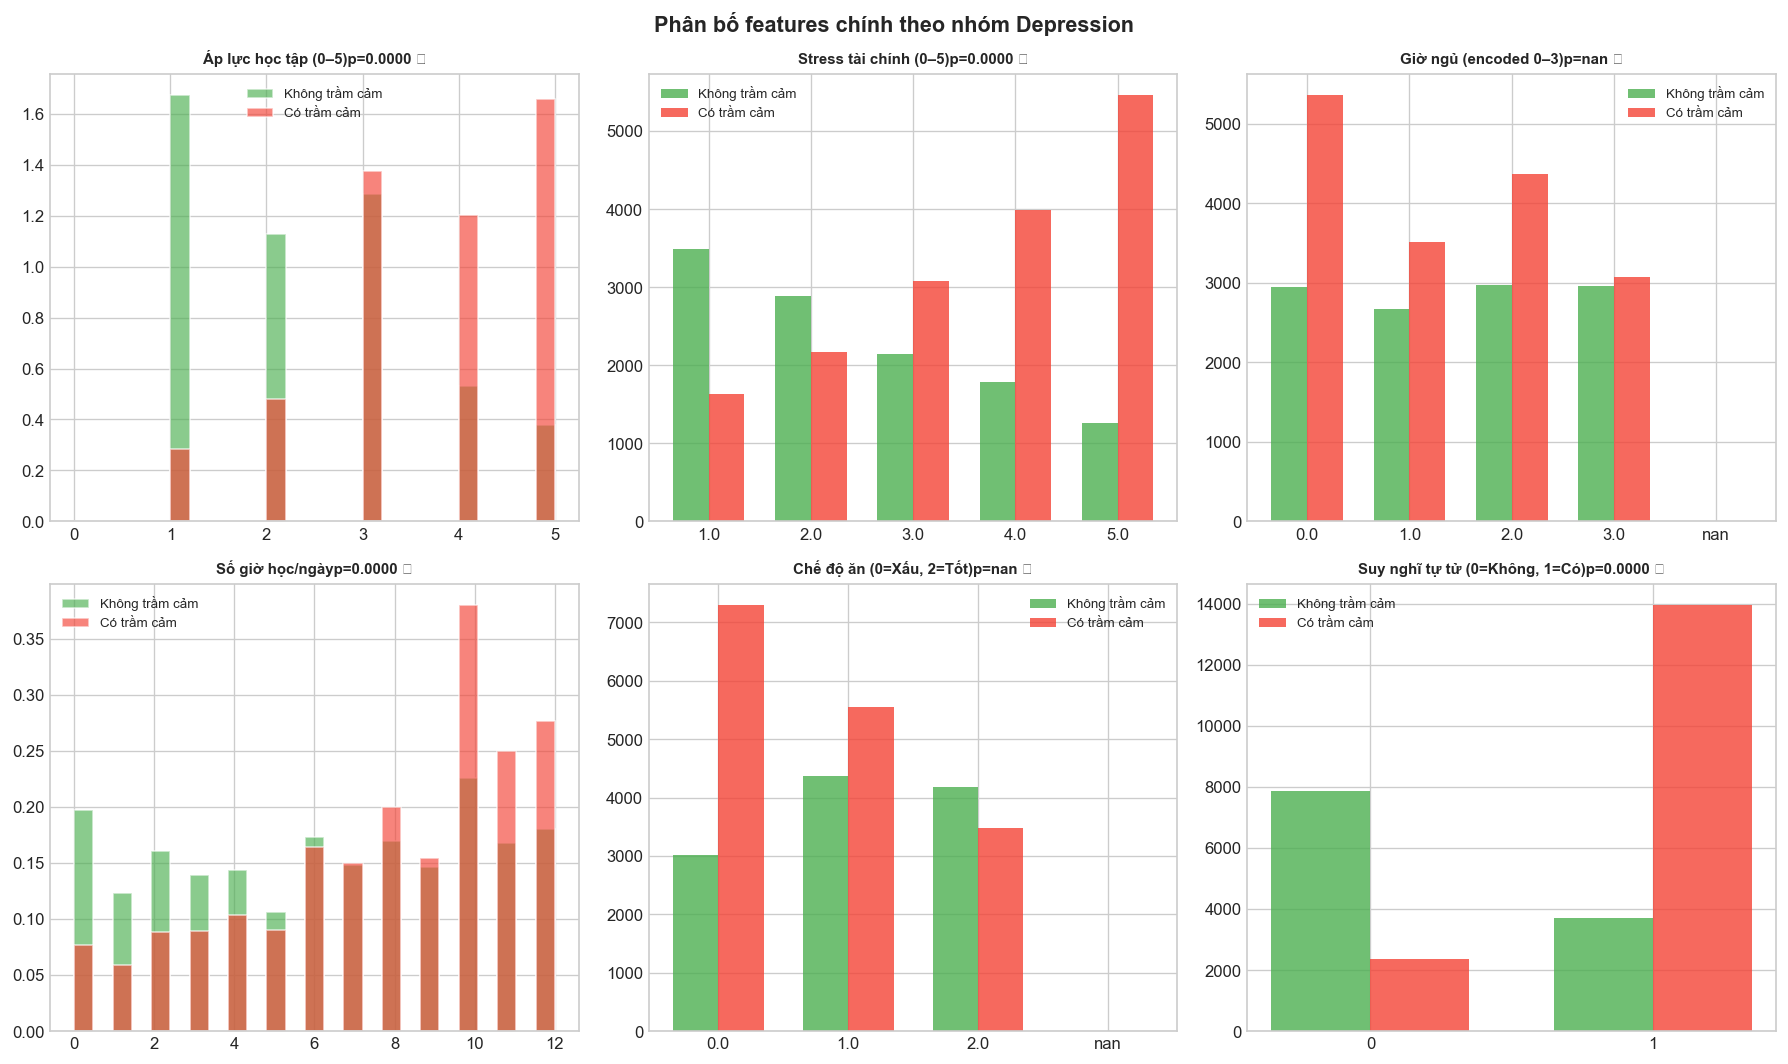

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

plot_feats = [
    ('Academic Pressure',  'Áp lực học tập (0–5)'),
    ('Financial Stress',   'Stress tài chính (0–5)'),
    ('Sleep Duration Enc', 'Giờ ngủ (encoded 0–3)'),
    ('Work/Study Hours',   'Số giờ học/ngày'),
    ('Dietary Habits Enc', 'Chế độ ăn (0=Xấu, 2=Tốt)'),
    ('Have you ever had suicidal thoughts ? Enc', 'Suy nghĩ tự tử (0=Không, 1=Có)'),
]

for ax, (feat, label) in zip(axes, plot_feats):
    data0 = df_clean[df_clean[TARGET_COL] == 0][feat]
    data1 = df_clean[df_clean[TARGET_COL] == 1][feat]

    # Dùng KDE nếu continuous, bar nếu discrete
    n_unique = df_clean[feat].nunique()
    if n_unique > 5:
        ax.hist(data0, bins=25, alpha=0.65, color=COLORS['0'],
                label='Không trầm cảm', edgecolor='white', density=True)
        ax.hist(data1, bins=25, alpha=0.65, color=COLORS['1'],
                label='Có trầm cảm', edgecolor='white', density=True)
    else:
        vals = sorted(df_clean[feat].unique())
        x = np.arange(len(vals))
        w = 0.35
        cnt0 = [data0.value_counts().get(v, 0) for v in vals]
        cnt1 = [data1.value_counts().get(v, 0) for v in vals]
        ax.bar(x - w/2, cnt0, w, color=COLORS['0'], label='Không trầm cảm', alpha=0.8)
        ax.bar(x + w/2, cnt1, w, color=COLORS['1'], label='Có trầm cảm', alpha=0.8)
        ax.set_xticks(x); ax.set_xticklabels(vals)

    t, p = ttest_ind(data0, data1)
    ax.set_title(f'{label}p={p:.4f} {"✅" if p<0.05 else "❌"}',
                 fontsize=9, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Phân bố features chính theo nhóm Depression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/02_feature_distributions.png', bbox_inches='tight')
plt.show()

#### 4.3.3 Tỷ lệ trầm cảm theo từng mức độ áp lực học tập & tài chính

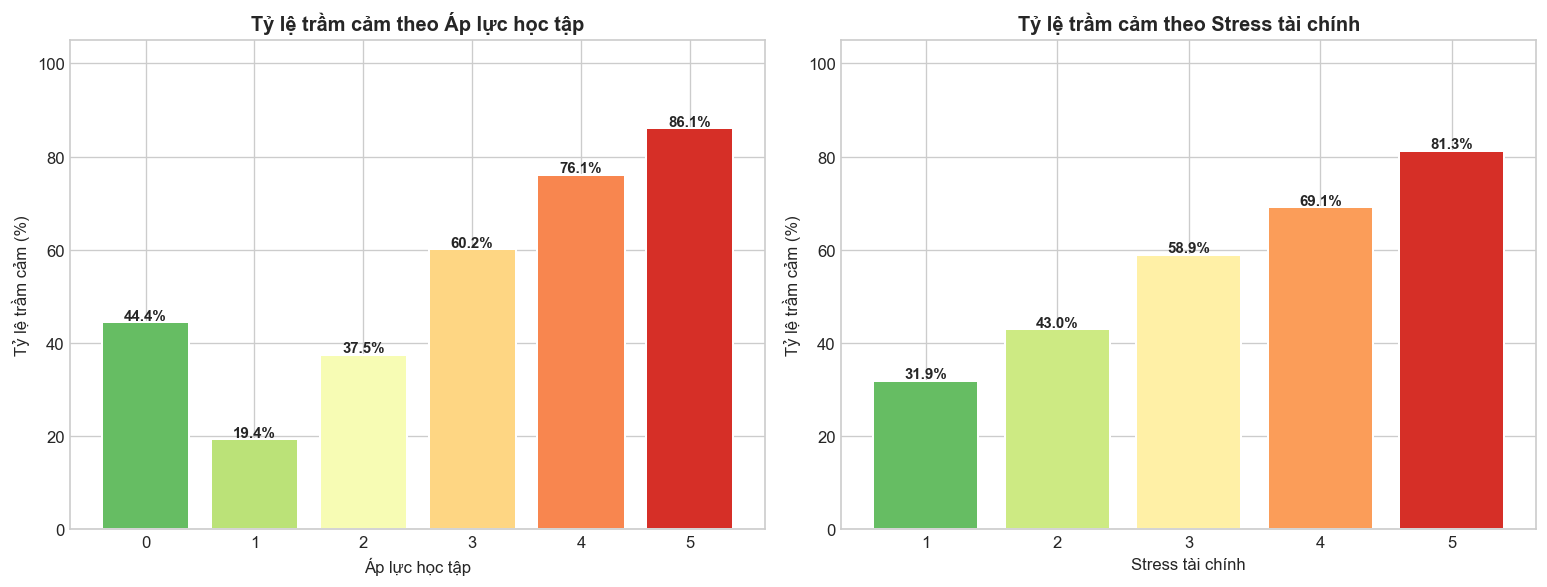

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, feat, title in [
    (axes[0], 'Academic Pressure', 'Áp lực học tập'),
    (axes[1], 'Financial Stress',  'Stress tài chính')
]:
    dep_rate = df_clean.groupby(feat)[TARGET_COL].mean() * 100
    bars = ax.bar(dep_rate.index, dep_rate.values,
                  color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.9, len(dep_rate))),
                  edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, dep_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(f'Tỷ lệ trầm cảm theo {title}', fontweight='bold')
    ax.set_xlabel(title); ax.set_ylabel('Tỷ lệ trầm cảm (%)')
    ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('charts/03_depression_by_pressure.png', bbox_inches='tight')
plt.show()

#### 4.3.4 Tỷ lệ trầm cảm theo giờ ngủ & chế độ ăn

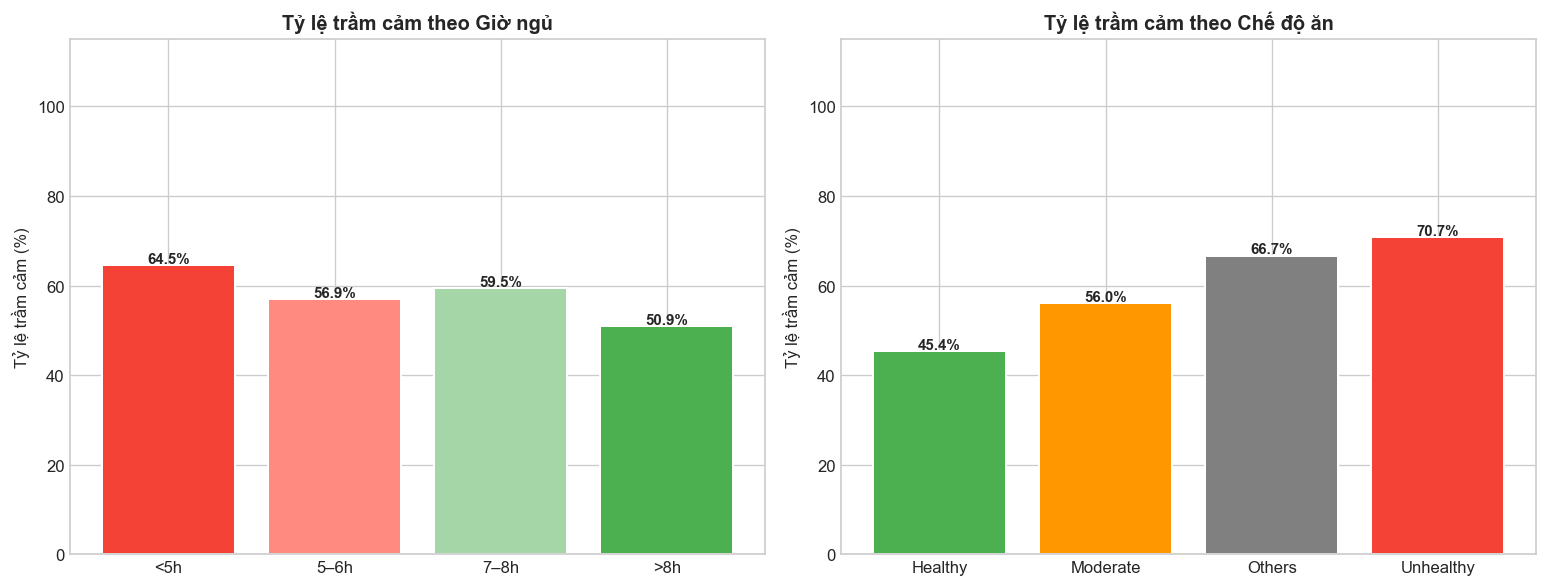

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Giờ ngủ
ax = axes[0]
sleep_dep = df_clean.groupby('Sleep Duration')[TARGET_COL].mean() * 100
sleep_dep = sleep_dep.reindex(['Less than 5 hours','5-6 hours','7-8 hours','More than 8 hours'])
bars = ax.bar(range(len(sleep_dep)), sleep_dep.values,
              color=[COLORS['1'], '#FF8A80', '#A5D6A7', COLORS['0']],
              edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, sleep_dep.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(range(len(sleep_dep)))
ax.set_xticklabels(['<5h', '5–6h', '7–8h', '>8h'])
ax.set_title('Tỷ lệ trầm cảm theo Giờ ngủ', fontweight='bold')
ax.set_ylabel('Tỷ lệ trầm cảm (%)')
ax.set_ylim(0, 115)

# Chế độ ăn
ax = axes[1]
diet_dep = df_clean.groupby('Dietary Habits')[TARGET_COL].mean() * 100
colors_diet = {'Unhealthy': COLORS['1'], 'Moderate': COLORS['orange'], 'Healthy': COLORS['0']}
bars = ax.bar(diet_dep.index, diet_dep.values,
              color=[colors_diet.get(k, 'gray') for k in diet_dep.index],
              edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, diet_dep.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Tỷ lệ trầm cảm theo Chế độ ăn', fontweight='bold')
ax.set_ylabel('Tỷ lệ trầm cảm (%)')
ax.set_ylim(0, 115)

plt.tight_layout()
plt.savefig('charts/04_depression_by_sleep_diet.png', bbox_inches='tight')
plt.show()

#### 4.3.5 Heatmap tương quan toàn bộ features

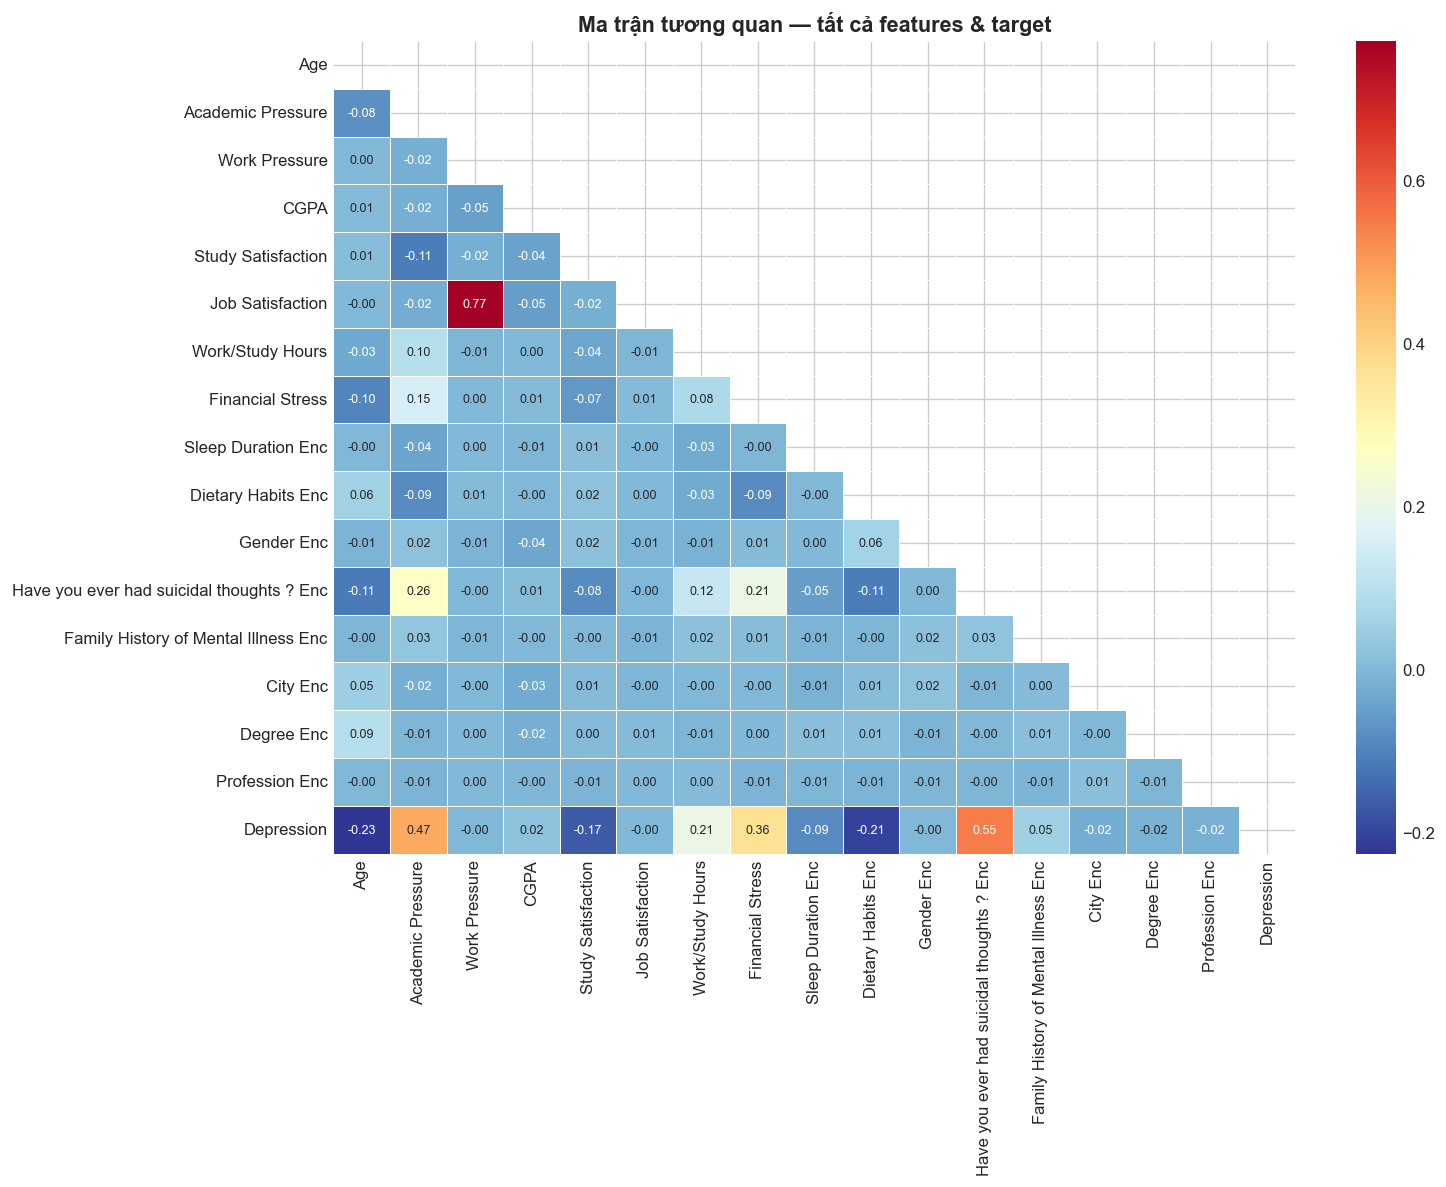

In [14]:
fig, ax = plt.subplots(figsize=(13, 10))
corr_mat = df_clean[FEATURES + [TARGET_COL]].corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            ax=ax, annot_kws={'size': 7.5}, linewidths=0.4)
ax.set_title('Ma trận tương quan — tất cả features & target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/05_correlation_heatmap.png', bbox_inches='tight')
plt.show()

#### 4.3.6 Phân bố suy nghĩ tự tử & tiền sử gia đình

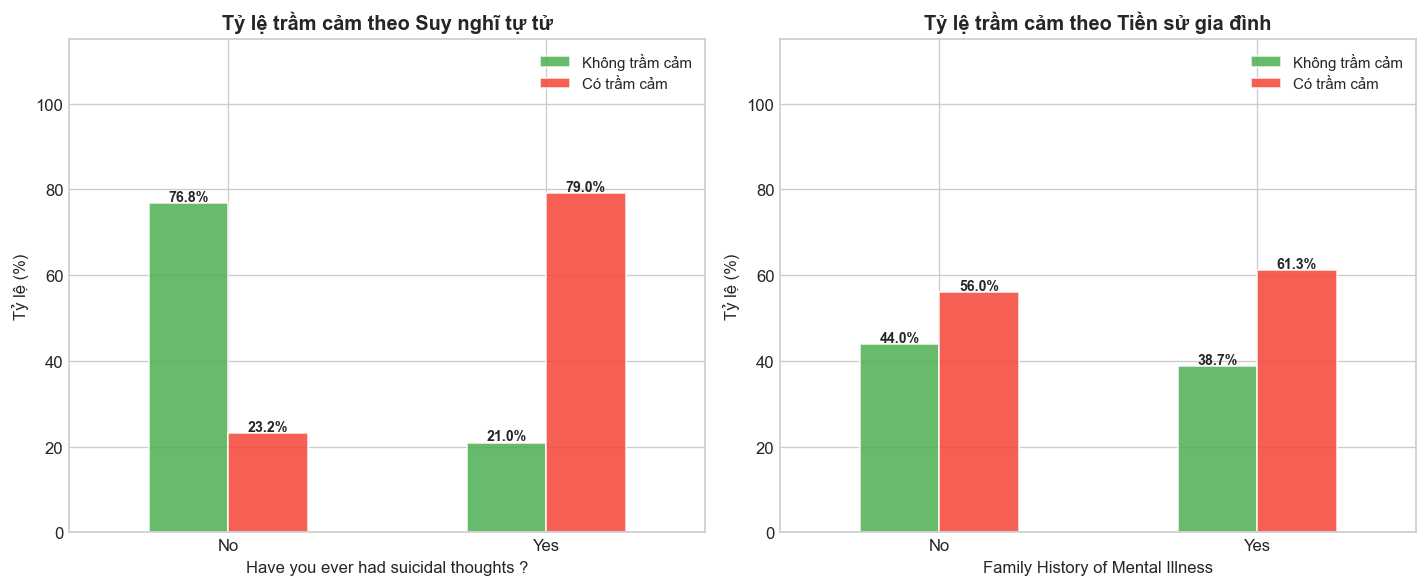

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, title in [
    (axes[0], 'Have you ever had suicidal thoughts ?', 'Suy nghĩ tự tử'),
    (axes[1], 'Family History of Mental Illness',      'Tiền sử gia đình'),
]:
    ct = pd.crosstab(df_clean[col], df_clean[TARGET_COL], normalize='index') * 100
    ct.columns = ['Không trầm cảm', 'Có trầm cảm']
    ct.plot(kind='bar', ax=ax, color=[COLORS['0'], COLORS['1']],
            edgecolor='white', alpha=0.85)
    ax.set_title(f'Tỷ lệ trầm cảm theo {title}', fontweight='bold')
    ax.set_ylabel('Tỷ lệ (%)'); ax.set_ylim(0, 115)
    ax.tick_params(axis='x', rotation=0)
    ax.legend(fontsize=9)
    for bar in ax.patches:
        h = bar.get_height()
        if h > 2:
            ax.text(bar.get_x()+bar.get_width()/2, h+0.5,
                    f'{h:.1f}%', ha='center', fontsize=8.5, fontweight='bold')

plt.tight_layout()
plt.savefig('charts/06_suicidal_family.png', bbox_inches='tight')
plt.show()

### 4.4 Bước 3 — Chia dữ liệu & Chuẩn hóa

In [16]:
# Chia train/test 80/20 stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Chuẩn hóa StandardScaler
scaler   = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
X_all_s   = scaler.transform(X)

print(f"✅ Train: {X_train_s.shape[0]:,} mẫu  |  Test: {X_test_s.shape[0]:,} mẫu  (80/20)")
print(f"   Train target: 0={( y_train==0).sum():,}  1={(y_train==1).sum():,}")
print(f"   Test  target: 0={( y_test==0).sum():,}  1={(y_test==1).sum():,}")
print(f"   Majority baseline: {max(y.mean(), 1-y.mean()):.4f}")

✅ Train: 22,320 mẫu  |  Test: 5,581 mẫu  (80/20)
   Train target: 0=9,252  1=13,068
   Test  target: 0=2,313  1=3,268
   Majority baseline: 0.5855


### 4.5 Bước 4 — Huấn luyện 4 mô hình

In [17]:
models = {
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000, solver='lbfgs', random_state=RANDOM_STATE
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=8, criterion='gini', random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=None,
        n_jobs=-1, random_state=RANDOM_STATE
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=5,
        eval_metric='logloss', verbosity=0, random_state=RANDOM_STATE
    ),
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}

for name, model in models.items():
    print(f"⏳ Huấn luyện: {name} ...")
    model.fit(X_train_s, y_train)

    y_pred = model.predict(X_test_s)
    y_prob = model.predict_proba(X_test_s)[:, 1]
    cv_acc = cross_val_score(model, X_all_s, y,
                              cv=cv_strategy, scoring='accuracy').mean()

    results[name] = {
        'model':     model,
        'y_pred':    y_pred,
        'y_prob':    y_prob,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred, zero_division=0),
        'F1-score':  f1_score(y_test, y_pred, zero_division=0),
        'AUC':       roc_auc_score(y_test, y_prob),
        'CV_Acc':    cv_acc,
    }
    r = results[name]
    print(f"   ✅  Acc={r['Accuracy']:.4f}  F1={r['F1-score']:.4f}  "
          f"AUC={r['AUC']:.4f}  CV={r['CV_Acc']:.4f}")

print("🎉 Hoàn tất huấn luyện!")

⏳ Huấn luyện: Logistic Regression ...
   ✅  Acc=0.8448  F1=0.8692  AUC=0.9183  CV=0.8467
⏳ Huấn luyện: Decision Tree ...
   ✅  Acc=0.8215  F1=0.8492  AUC=0.8919  CV=0.8260
⏳ Huấn luyện: Random Forest ...
   ✅  Acc=0.8411  F1=0.8664  AUC=0.9151  CV=0.8415
⏳ Huấn luyện: XGBoost ...
   ✅  Acc=0.8432  F1=0.8678  AUC=0.9172  CV=0.8446
🎉 Hoàn tất huấn luyện!


## Chương 5 — Kết quả

### 5.1 Bảng tổng hợp hiệu suất

In [18]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC', 'CV_Acc']
df_res  = pd.DataFrame({n: {m: round(results[n][m], 4) for m in metrics}
                        for n in results}).T
df_res.index.name = 'Mô hình'

majority_bl = max(y.mean(), 1 - y.mean())
df_res.loc['Majority Baseline'] = [round(majority_bl,4)]*2 + [0,0] + [0.5, round(majority_bl,4)]

def highlight_max(s):
    v = s[:-1].astype(float)
    return ['background-color:#bbdefb;color:black;font-weight:bold'
            if (i < len(s)-1 and s.iloc[i] == v.max()) else ''
            for i in range(len(s))]

print(f"Majority Baseline (predict all 0): {majority_bl:.4f}")
df_res.style.apply(highlight_max).format("{:.4f}")

Majority Baseline (predict all 0): 0.5855


,Accuracy,Precision,Recall,F1-score,AUC,CV_Acc
Mô hình,,,,,,
Logistic Regression,0.8448,0.8583,0.8804,0.8692,0.9183,0.8467
Decision Tree,0.8215,0.8405,0.8580,0.8492,0.8919,0.8260
Random Forest,0.8411,0.8532,0.8800,0.8664,0.9151,0.8415
XGBoost,0.8432,0.8571,0.8788,0.8678,0.9172,0.8446
Majority Baseline,0.5855,0.5855,0.0000,0.0000,0.5000,0.5855


### 5.2 Classification Report chi tiết

In [19]:
for name, r in results.items():
    print(f"{'='*58}")
    print(f"  {name}")
    print(f"{'='*58}")
    print(classification_report(y_test, r['y_pred'],
                                 target_names=['Không trầm cảm (0)', 'Có trầm cảm (1)']))

  Logistic Regression
                    precision    recall  f1-score   support

Không trầm cảm (0)       0.82      0.79      0.81      2313
   Có trầm cảm (1)       0.86      0.88      0.87      3268

          accuracy                           0.84      5581
         macro avg       0.84      0.84      0.84      5581
      weighted avg       0.84      0.84      0.84      5581

  Decision Tree
                    precision    recall  f1-score   support

Không trầm cảm (0)       0.79      0.77      0.78      2313
   Có trầm cảm (1)       0.84      0.86      0.85      3268

          accuracy                           0.82      5581
         macro avg       0.82      0.81      0.82      5581
      weighted avg       0.82      0.82      0.82      5581

  Random Forest
                    precision    recall  f1-score   support

Không trầm cảm (0)       0.82      0.79      0.80      2313
   Có trầm cảm (1)       0.85      0.88      0.87      3268

          accuracy                    

### 5.3 Biểu đồ so sánh hiệu suất

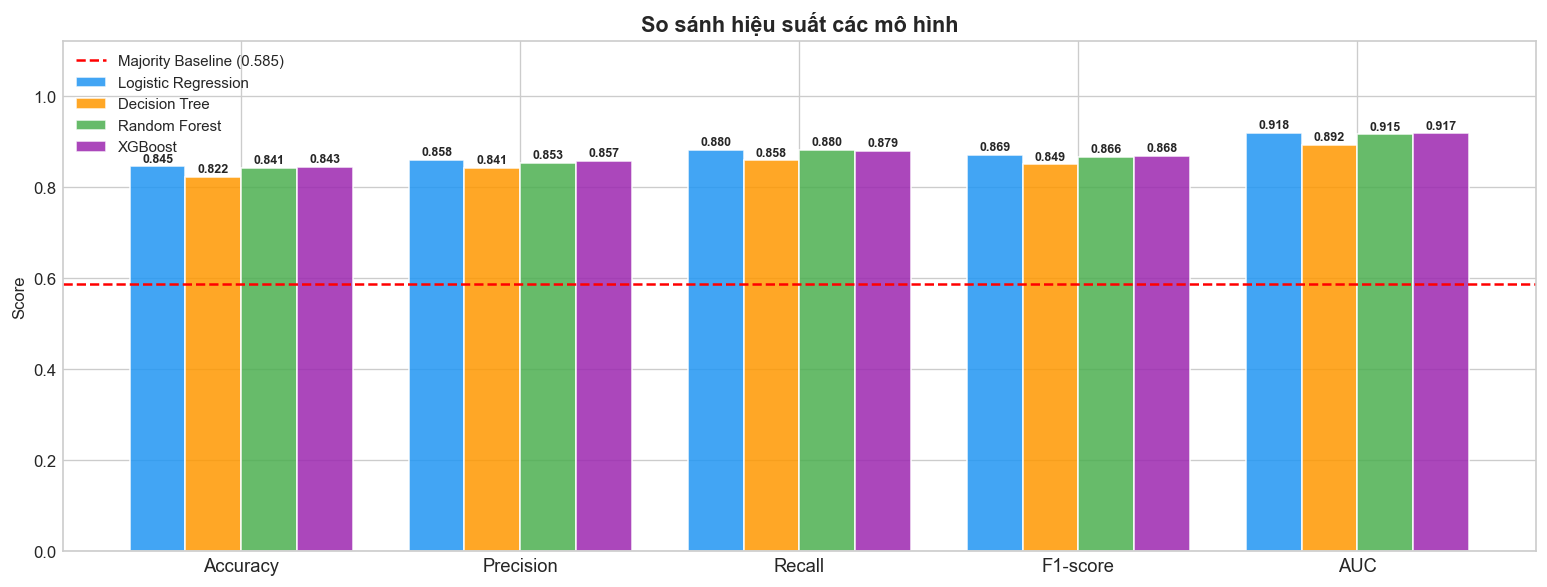

In [20]:
bar_colors   = [COLORS['blue'], COLORS['orange'], COLORS['0'], COLORS['purple']]
show_metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC']
x, width     = np.arange(len(show_metrics)), 0.20

fig, ax = plt.subplots(figsize=(13, 5))
for i, (name, color) in enumerate(zip(results.keys(), bar_colors)):
    vals  = [results[name][m] for m in show_metrics]
    rects = ax.bar(x + i*width, vals, width, label=name,
                   color=color, alpha=0.85, edgecolor='white')
    for rect, v in zip(rects, vals):
        ax.text(rect.get_x()+rect.get_width()/2, rect.get_height()+0.004,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.axhline(majority_bl, color='red', ls='--', lw=1.5,
           label=f'Majority Baseline ({majority_bl:.3f})')
ax.set_xticks(x + width*1.5); ax.set_xticklabels(show_metrics, fontsize=11)
ax.set_ylim(0, 1.12); ax.set_ylabel('Score')
ax.set_title('So sánh hiệu suất các mô hình', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('charts/07_model_comparison.png', bbox_inches='tight')
plt.show()

### 5.4 Confusion Matrix

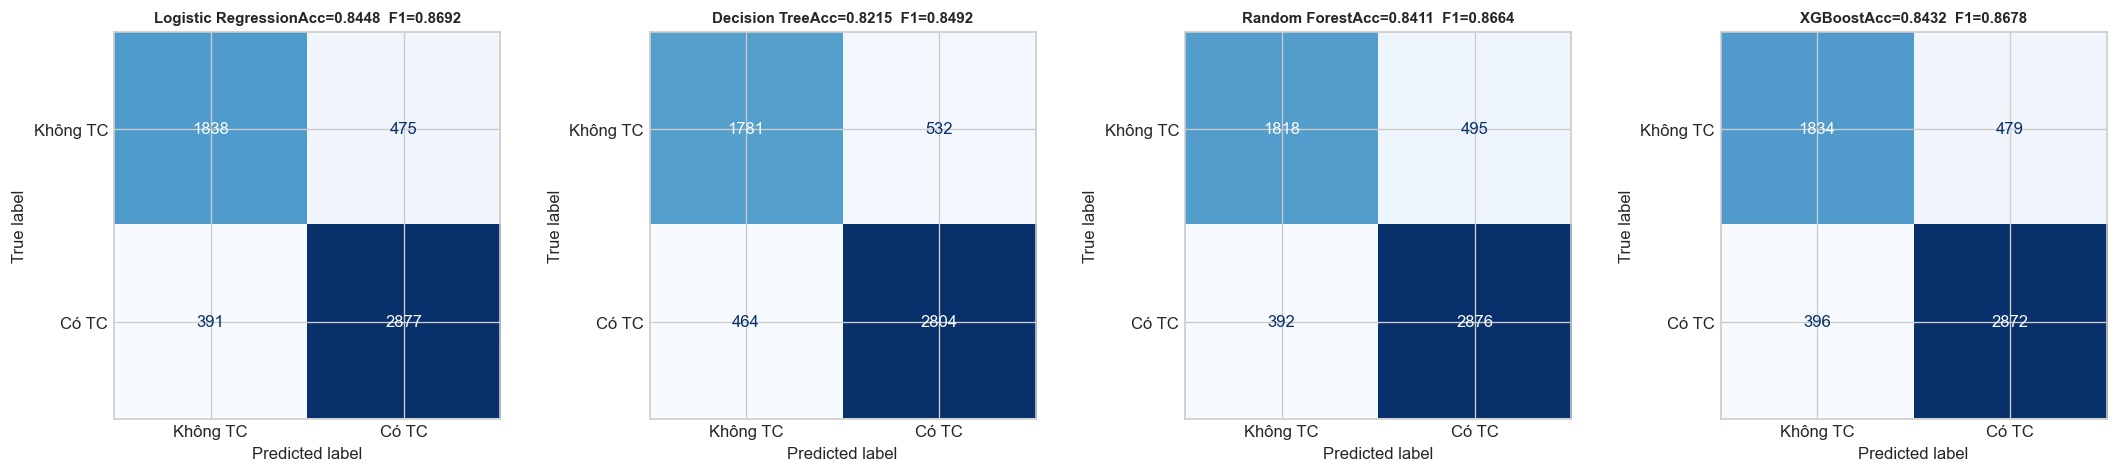

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, r) in zip(axes, results.items()):
    cm   = confusion_matrix(y_test, r['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Không TC', 'Có TC'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}Acc={r["Accuracy"]:.4f}  F1={r["F1-score"]:.4f}',
                 fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/08_confusion_matrices.png', bbox_inches='tight')
plt.show()

### 5.5 ROC Curve

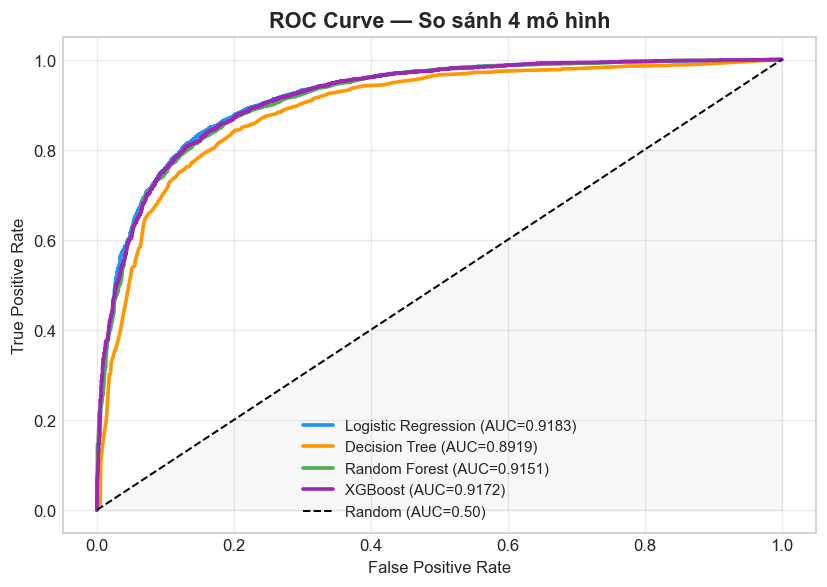

In [22]:
fig, ax = plt.subplots(figsize=(7, 5))
for (name, r), color in zip(results.items(), bar_colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    ax.plot(fpr, tpr, lw=2.2, color=color,
            label=f"{name} (AUC={r['AUC']:.4f})")
ax.plot([0,1],[0,1], 'k--', lw=1.2, label='Random (AUC=0.50)')
ax.fill_between([0,1],[0,1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — So sánh 4 mô hình', fontsize=13, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('charts/09_roc_curve.png', bbox_inches='tight')
plt.show()

### 5.6 Feature Importance — Random Forest & XGBoost

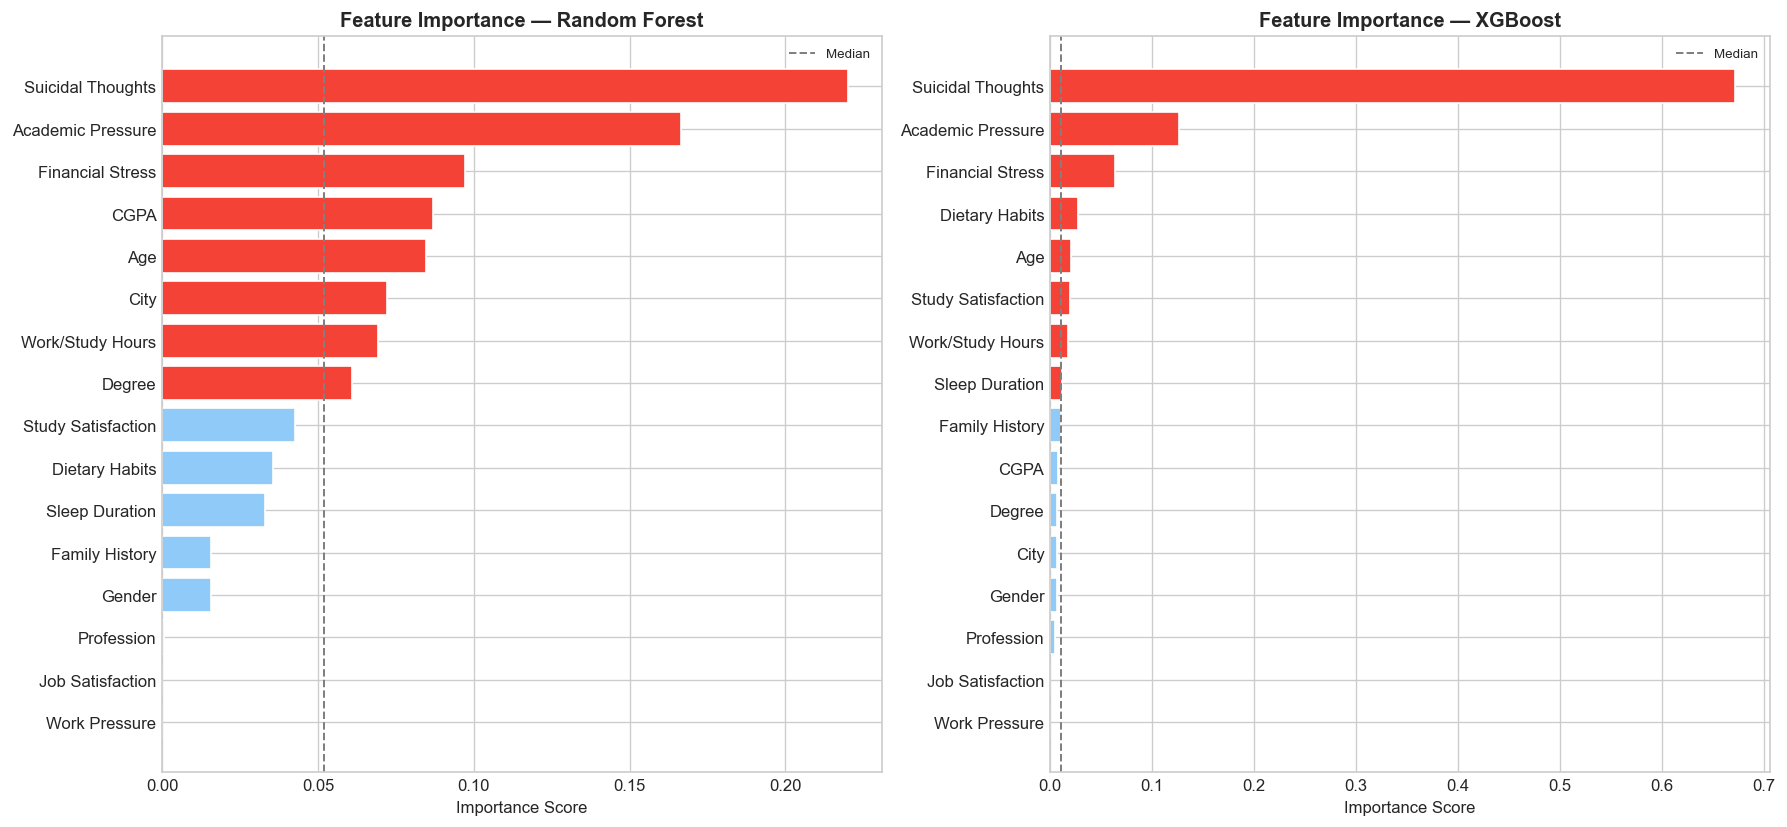

Top 5 features quan trọng nhất (Random Forest):
  Suicidal Thoughts              0.2200  ████████████████████████████████████████████
  Academic Pressure              0.1664  █████████████████████████████████
  Financial Stress               0.0972  ███████████████████
  CGPA                           0.0868  █████████████████
  Age                            0.0845  ████████████████


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

feat_labels = [
    'Age', 'Academic Pressure', 'Work Pressure', 'CGPA',
    'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress',
    'Sleep Duration', 'Dietary Habits', 'Gender',
    'Suicidal Thoughts', 'Family History', 'City', 'Degree', 'Profession'
]

for ax, mname, title in [
    (axes[0], 'Random Forest', 'Random Forest'),
    (axes[1], 'XGBoost',       'XGBoost'),
]:
    imp = pd.Series(results[mname]['model'].feature_importances_,
                    index=feat_labels).sort_values(ascending=True)
    colors_imp = ['#F44336' if v >= imp.median() else '#90CAF9'
                  for v in imp.values]
    ax.barh(imp.index, imp.values, color=colors_imp, edgecolor='white')
    ax.axvline(imp.median(), color='gray', ls='--', lw=1.2, label='Median')
    ax.set_title(f'Feature Importance — {title}', fontweight='bold')
    ax.set_xlabel('Importance Score'); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('charts/10_feature_importance.png', bbox_inches='tight')
plt.show()

print("Top 5 features quan trọng nhất (Random Forest):")
rf_imp = pd.Series(results['Random Forest']['model'].feature_importances_,
                   index=feat_labels).sort_values(ascending=False)
for feat, imp in rf_imp.head(5).items():
    print(f"  {feat:<30} {imp:.4f}  {'█'*int(imp*200)}")

### 5.7 Cross-Validation Accuracy theo từng fold

  Logistic Regression    ['  Fold1=0.8527', '  Fold2=0.8448', '  Fold3=0.8448', '  Fold4=0.8416', '  Fold5=0.8496']  → Mean=0.8467
  Decision Tree          ['  Fold1=0.8273', '  Fold2=0.8289', '  Fold3=0.8238', '  Fold4=0.8208', '  Fold5=0.8294']  → Mean=0.8260
  Random Forest          ['  Fold1=0.8445', '  Fold2=0.8373', '  Fold3=0.8425', '  Fold4=0.8403', '  Fold5=0.8430']  → Mean=0.8415
  XGBoost                ['  Fold1=0.8500', '  Fold2=0.8428', '  Fold3=0.8439', '  Fold4=0.8400', '  Fold5=0.8464']  → Mean=0.8446


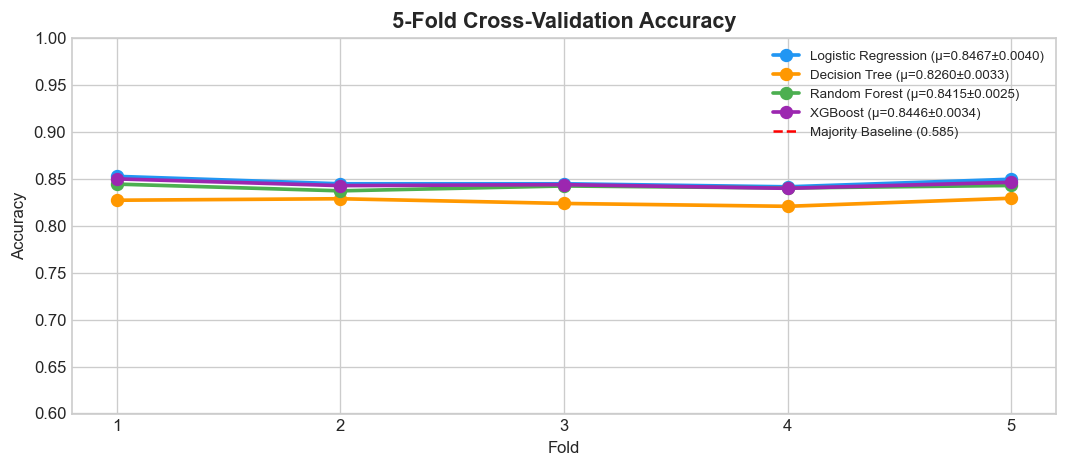

In [24]:
fig, ax = plt.subplots(figsize=(9, 4))
for (name, model), color in zip(models.items(), bar_colors):
    scores = cross_val_score(model, X_all_s, y, cv=cv_strategy, scoring='accuracy')
    ax.plot(range(1,6), scores, marker='o', lw=2.2, color=color, markersize=7,
            label=f'{name} (μ={scores.mean():.4f}±{scores.std():.4f})')
    print(f"  {name:<22} {['  Fold'+str(i+1)+'='+f'{s:.4f}' for i,s in enumerate(scores)]}"
          f"  → Mean={scores.mean():.4f}")

ax.axhline(majority_bl, color='red', ls='--', lw=1.5,
           label=f'Majority Baseline ({majority_bl:.3f})')
ax.set_xlabel('Fold'); ax.set_ylabel('Accuracy')
ax.set_title('5-Fold Cross-Validation Accuracy', fontsize=13, fontweight='bold')
ax.set_xticks(range(1,6)); ax.set_ylim(0.6, 1.0)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('charts/11_cross_validation.png', bbox_inches='tight')
plt.show()

### 5.8 Visualize Decision Tree (3 mức đầu)

Cấu trúc Decision Tree (3 mức đầu):
|--- Suicidal Thoughts <= -0.28
|   |--- Academic Pressure <= 0.26
|   |   |--- Financial Stress <= -0.44
|   |   |   |--- Dietary Habits <= -0.51
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- Dietary Habits >  -0.51
|   |   |   |   |--- truncated branch of depth 5
|   |   |--- Financial Stress >  -0.44
|   |   |   |--- Academic Pressure <= -1.19
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- Academic Pressure >  -1.19
|   |   |   |   |--- truncated branch of depth 5
|   |--- Academic Pressure >  0.26
|   |   |--- Financial Stress <= -0.44
|   |   |   |--- Age <= -0.07
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- Age >  -0.07
|   |   |   |   |--- truncated branch of depth 5
|   |   |--- Financial Stress >  -0.44
|   |   |   |--- Financial Stress <= 0.95
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- Financial Stress >  0.95
|   |   |   |   |--- truncated branch of depth 5


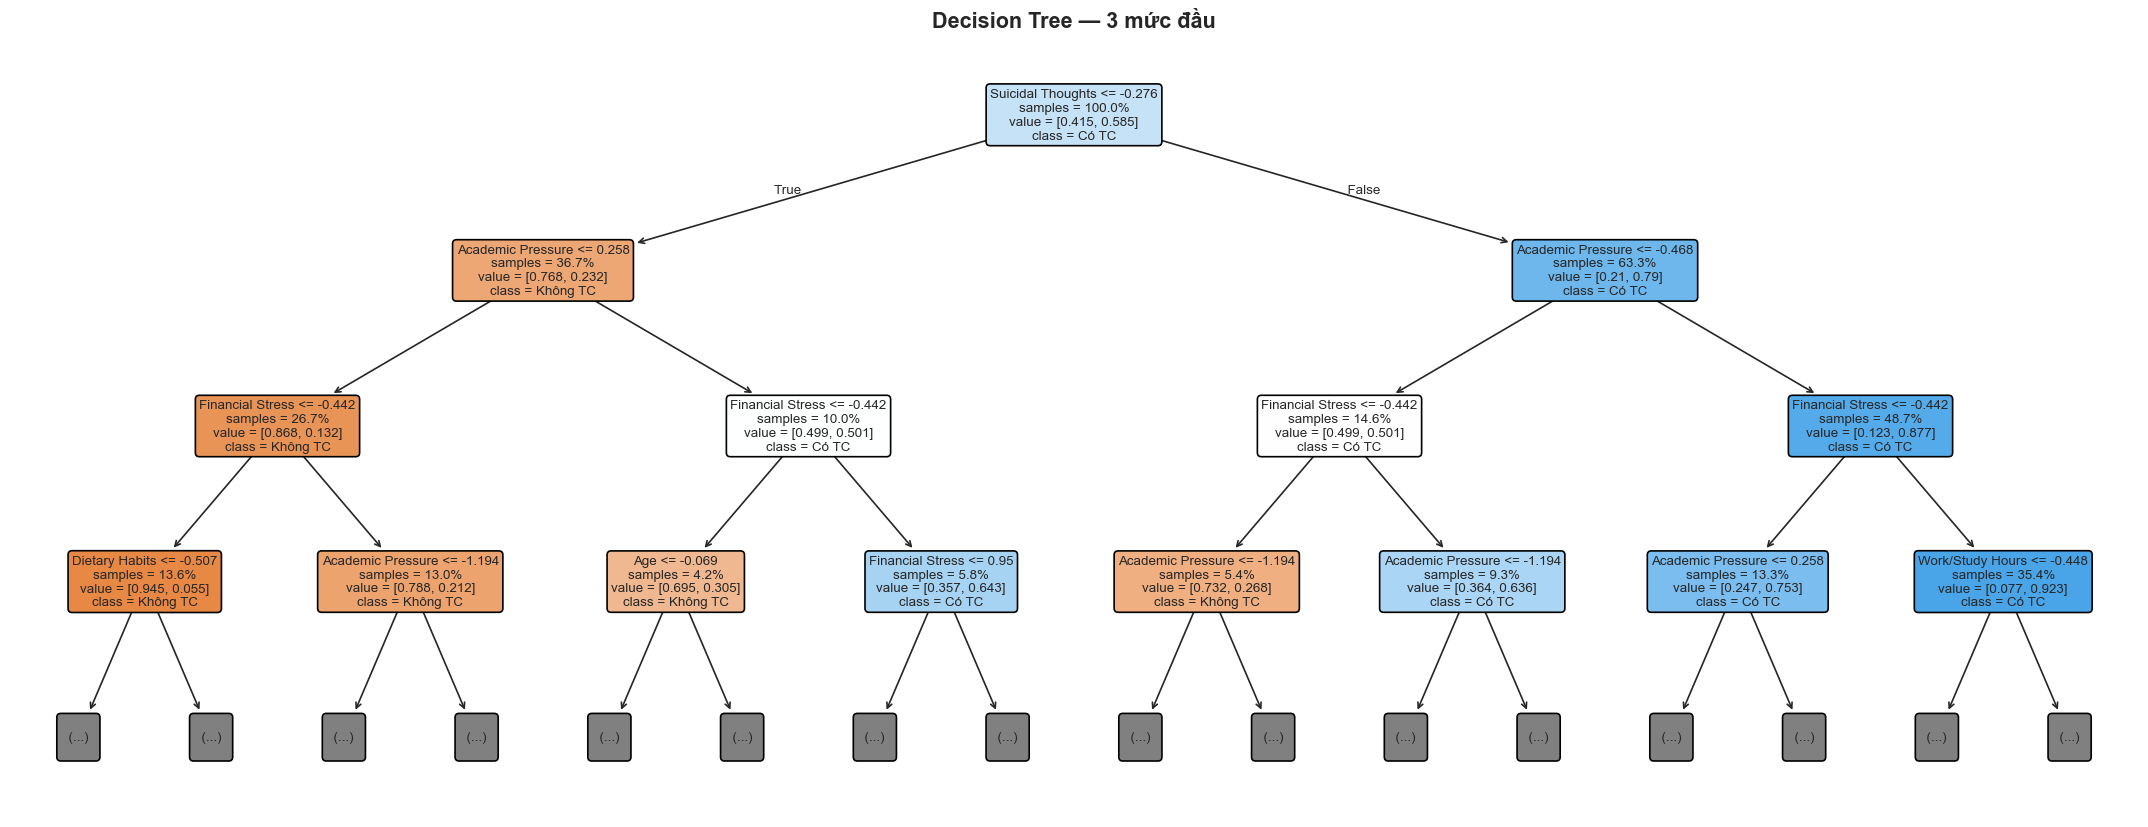

In [25]:
dt_model = results['Decision Tree']['model']
print("Cấu trúc Decision Tree (3 mức đầu):")
rules = export_text(dt_model, feature_names=feat_labels, max_depth=3)
print(rules)

fig, ax = plt.subplots(figsize=(18, 7))
plot_tree(dt_model, feature_names=feat_labels,
          class_names=['Không TC', 'Có TC'],
          filled=True, max_depth=3, ax=ax,
          impurity=False, proportion=True, rounded=True,
          fontsize=8)
ax.set_title('Decision Tree — 3 mức đầu', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/12_decision_tree.png', bbox_inches='tight', dpi=150)
plt.show()

### 5.9 Trả lời câu hỏi nghiên cứu

In [26]:
best_name  = max(results, key=lambda k: results[k]['AUC'])
best_acc   = results[best_name]['Accuracy']
best_auc   = results[best_name]['AUC']
best_f1    = results[best_name]['F1-score']
best_cv    = results[best_name]['CV_Acc']

print("╔══════════════════════════════════════════════════════════════════╗")
print("║  CÂU HỎI NGHIÊN CỨU                                             ║")
print("╠══════════════════════════════════════════════════════════════════╣")
print("║  Dựa vào áp lực học tập, giờ ngủ, stress tài chính và lối       ║")
print("║  sống, sinh viên có bị trầm cảm không?                          ║")
print("╠══════════════════════════════════════════════════════════════════╣")
print("║  TRẢ LỜI: CÓ — mô hình dự đoán được với độ chính xác cao       ║")
print("╚══════════════════════════════════════════════════════════════════╝")
print()
print(f"  Mô hình tốt nhất: {best_name}")
print(f"  ├─ Accuracy:        {best_acc:.4f} ({best_acc*100:.1f}%)")
print(f"  ├─ AUC-ROC:         {best_auc:.4f}")
print(f"  ├─ F1-score:        {best_f1:.4f}")
print(f"  └─ CV-5fold:        {best_cv:.4f}")
print()
print("  Các yếu tố dự báo trầm cảm mạnh nhất:")
rf_imp2 = pd.Series(results['Random Forest']['model'].feature_importances_,
                    index=feat_labels).sort_values(ascending=False)
for i, (feat, imp) in enumerate(rf_imp2.head(5).items(), 1):
    print(f"    {i}. {feat:<30} importance = {imp:.4f}")

╔══════════════════════════════════════════════════════════════════╗
║  CÂU HỎI NGHIÊN CỨU                                             ║
╠══════════════════════════════════════════════════════════════════╣
║  Dựa vào áp lực học tập, giờ ngủ, stress tài chính và lối       ║
║  sống, sinh viên có bị trầm cảm không?                          ║
╠══════════════════════════════════════════════════════════════════╣
║  TRẢ LỜI: CÓ — mô hình dự đoán được với độ chính xác cao       ║
╚══════════════════════════════════════════════════════════════════╝

  Mô hình tốt nhất: Logistic Regression
  ├─ Accuracy:        0.8448 (84.5%)
  ├─ AUC-ROC:         0.9183
  ├─ F1-score:        0.8692
  └─ CV-5fold:        0.8467

  Các yếu tố dự báo trầm cảm mạnh nhất:
    1. Suicidal Thoughts              importance = 0.2200
    2. Academic Pressure              importance = 0.1664
    3. Financial Stress               importance = 0.0972
    4. CGPA                           importance = 0.0868
    5. Age     

## Chương 6 — Thảo luận & Kết luận

### 6.1 Khả năng ứng dụng

- **Hệ thống cảnh báo sớm** tích hợp vào cổng thông tin sinh viên: cảnh báo tự động
  khi phát hiện sinh viên có nguy cơ trầm cảm cao
- **Hỗ trợ tư vấn tâm lý học đường**: phân loại ưu tiên sinh viên cần can thiệp khẩn
- **Nghiên cứu chính sách giáo dục**: xác định yếu tố nào cần cải thiện
  (giảm áp lực học tập, hỗ trợ tài chính, cải thiện điều kiện ngủ)

### 6.2 Ưu điểm & Nhược điểm

| Ưu điểm ✅ | Nhược điểm ❌ |
|---|---|
| Dữ liệu thực, tương quan có ý nghĩa thống kê | Dữ liệu tự khai báo — có thể có response bias |
| 4 thuật toán so sánh khách quan | Chưa áp dụng hyperparameter tuning (GridSearchCV) |
| Cross-Validation 5-fold đảm bảo độ ổn định | Dữ liệu không cân bằng nhẹ — có thể cần SMOTE |
| Feature Importance giải thích rõ ràng | Chưa có explainability nâng cao (SHAP/LIME) |
| Quy trình tiền xử lý hoàn chỉnh | Chưa xét tương tác giữa các features |

### 6.3 Đề xuất cải thiện

1. **Hyperparameter Tuning**: Dùng `GridSearchCV` hoặc `Optuna` để tối ưu tham số
2. **SHAP values**: Phân tích đóng góp từng feature cho từng dự đoán cụ thể
3. **SMOTE**: Xử lý mất cân bằng lớp nếu cần để cải thiện Recall
4. **Ensemble nâng cao**: Stacking/Blending các mô hình để tăng AUC
5. **Thu thập thêm features**: Số giờ ngủ thực tế (từ thiết bị đeo), mức độ giao tiếp xã hội

---
## Tài liệu tham khảo

1. Shamim, A. (2025). *Student Depression Dataset*. Kaggle. https://www.kaggle.com/datasets/adilshamim8/student-depression-dataset
2. Noviandy, T.R., et al. (2025). An Explainable ML Study of Behavioral and Psychological Determinants of Depression. *Journal of Educational Management and Learning*, 3(1), 22–31.
3. Zhou, T., et al. (2021). Associations between Sleep Duration, Academic Pressure, and Depressive Symptoms. *IJERPH*, 18(11), 6134.
4. Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR*, 12, 2825–2830.
5. Chen, T., & Guestrin, C. (2016). XGBoost: A Scalable Tree Boosting System. *KDD 2016*.
6. Breiman, L. (2001). Random Forests. *Machine Learning*, 45(1), 5–32.
7. WHO. (2023). *Depressive disorder (depression)*. World Health Organization Fact Sheet.

In [27]:
print("✅ HOÀN TẤT — Tất cả biểu đồ đã lưu vào thư mục 'charts/':")
for f in sorted(os.listdir('charts')):
    print(f"   📊 charts/{f}")

✅ HOÀN TẤT — Tất cả biểu đồ đã lưu vào thư mục 'charts/':
   📊 charts/01_target_distribution.png
   📊 charts/02_feature_distributions.png
   📊 charts/03_depression_by_pressure.png
   📊 charts/04_depression_by_sleep_diet.png
   📊 charts/05_correlation_heatmap.png
   📊 charts/06_suicidal_family.png
   📊 charts/07_model_comparison.png
   📊 charts/08_confusion_matrices.png
   📊 charts/09_roc_curve.png
   📊 charts/10_feature_importance.png
   📊 charts/11_cross_validation.png
   📊 charts/12_decision_tree.png
